# Session 3

In [1]:
import pandas as pd
import numpy as np
import sklearn
import scipy
import matplotlib.pyplot as plt
from sklearn import preprocessing

### Distanzberechnung

In [2]:
pointA = [1,2,3]
pointB = [3,2,1]
pointC = [4,7,1]

In [3]:
# Einfache Distanzberechnung:
scipy.spatial.distance.pdist([pointA, pointB], metric="minkowski", p=2)

array([2.82842712])

In [4]:
# Manueller Check
sum([(x1 - x2)**2 for x1, x2 in zip(pointA, pointB)])**(1/2)

2.8284271247461903

In [5]:
# Matrix an Distanzen
scipy.spatial.distance.squareform(scipy.spatial.distance.pdist([pointA, pointB, pointC], metric="minkowski", p=2))

array([[0.        , 2.82842712, 6.164414  ],
       [2.82842712, 0.        , 5.09901951],
       [6.164414  , 5.09901951, 0.        ]])

In [6]:
# Distanzberechnung zwischen zwei Listen an Distanzen
scipy.spatial.distance.cdist([pointA, pointB], [pointB, pointC], metric="minkowski", p=2)

array([[2.82842712, 6.164414  ],
       [0.        , 5.09901951]])

### Skalierung

In [12]:
iris_data = pd.read_csv('..\\Data\\Raw\\iris.csv').drop("Id", axis=1)
iris_data

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


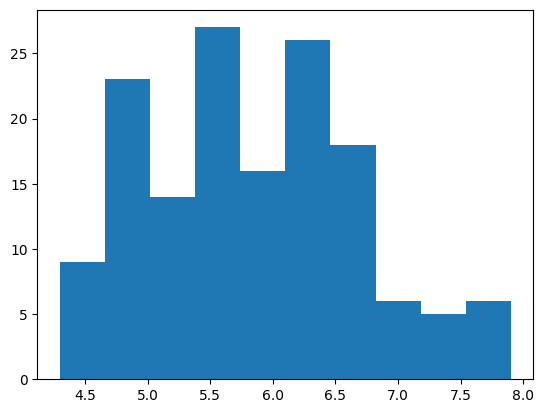

In [14]:
original_data = iris_data[["SepalLengthCm"]]
plt.hist(original_data)
plt.show()

In [15]:
original_data.describe()

,SepalLengthCm
count,150.000000
mean,5.843333
std,0.828066
min,4.300000
25%,5.100000
50%,5.800000
75%,6.400000
max,7.900000


#### MinMax Skalierung


In [16]:
(original_data - original_data.min()) / (original_data.max() - original_data.min())

,SepalLengthCm
0,0.222222
1,0.166667
2,0.111111
3,0.083333
4,0.194444
...,...
145,0.666667
146,0.555556
147,0.611111
148,0.527778


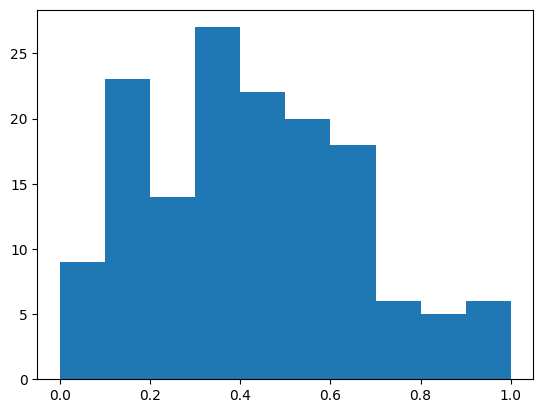

In [17]:
minmax_scaler = sklearn.preprocessing.MinMaxScaler()
scaled_data = minmax_scaler.fit_transform(original_data)
plt.hist(scaled_data)
plt.show()

In [18]:
pd.DataFrame(scaled_data).describe()

,0
count,150.000000
mean,0.428704
std,0.230018
min,0.000000
25%,0.222222
50%,0.416667
75%,0.583333
max,1.000000


#### Standardisierung

In [19]:
# Manueller Weg
(original_data - original_data.mean()) / original_data.std()

,SepalLengthCm
0,-0.897674
1,-1.139200
2,-1.380727
3,-1.501490
4,-1.018437
...,...
145,1.034539
146,0.551486
147,0.793012
148,0.430722


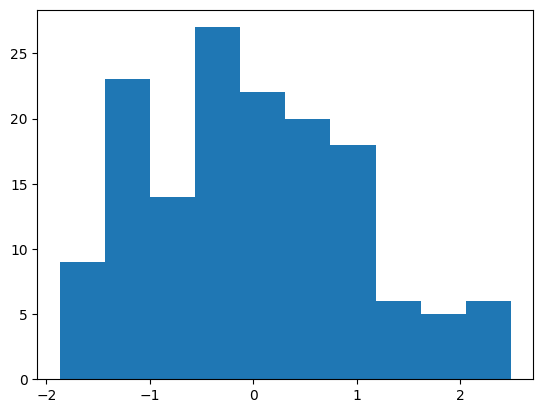

In [20]:
standard_scaler = sklearn.preprocessing.StandardScaler()
standard_data = standard_scaler.fit_transform(original_data)
plt.hist(standard_data)
plt.show()

In [21]:
pd.DataFrame(standard_data).describe()

,0
count,1.500000e+02
mean,-4.736952e-16
std,1.003350e+00
min,-1.870024e+00
25%,-9.006812e-01
50%,-5.250608e-02
75%,6.745011e-01
max,2.492019e+00


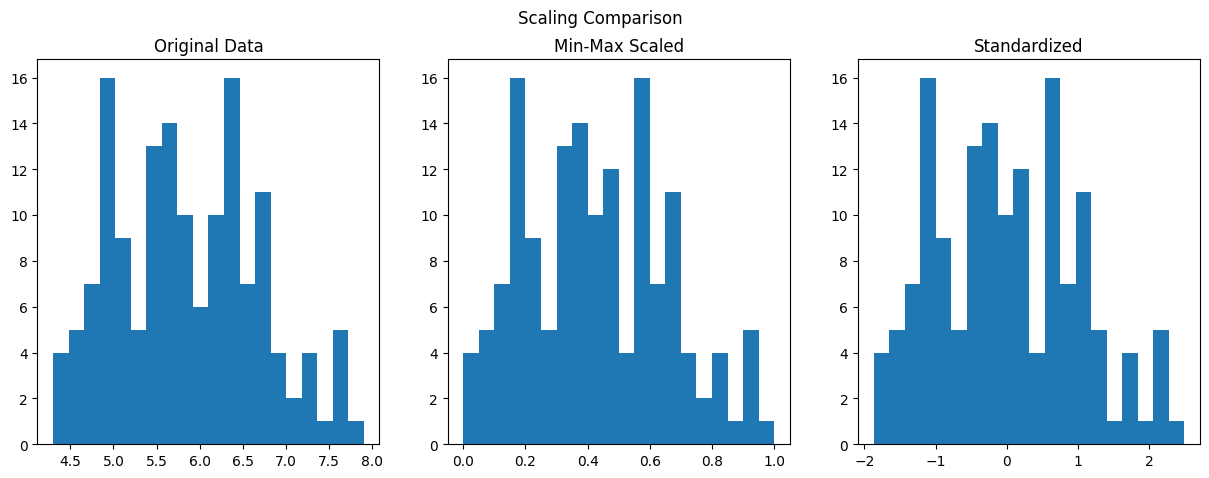

In [22]:
fig, axs = plt.subplots(1,3, figsize=(15,5))

axs[0].hist(original_data, bins=20)
axs[0].set_title("Original Data")

axs[1].hist(minmax_scaler.fit_transform(original_data), bins=20)
axs[1].set_title("Min-Max Scaled")

axs[2].hist(standard_scaler.fit_transform(original_data), bins=20)
axs[2].set_title("Standardized")

fig.suptitle("Scaling Comparison")
plt.show()

Keine Änderung der Distribution, sondern nur Skalierung

#### Einfluss von Outliern auf Skalierung

In [23]:
outlier_data = pd.concat([original_data, pd.DataFrame([20], columns=["SepalLengthCm"])]).reset_index(drop=True)
outlier_data.tail(5)

,SepalLengthCm
146,6.3
147,6.5
148,6.2
149,5.9
150,20.0


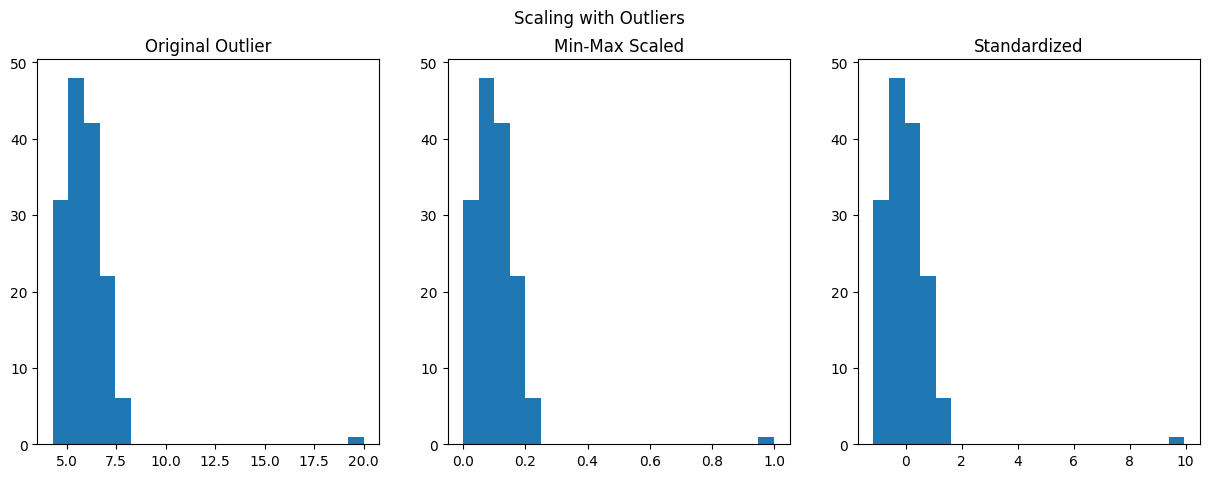

In [24]:
fig, axs = plt.subplots(1,3, figsize=(15,5))

axs[0].hist(outlier_data, bins=20)
axs[0].set_title("Original Outlier")

axs[1].hist(minmax_scaler.fit_transform(outlier_data), bins=20)
axs[1].set_title("Min-Max Scaled")

axs[2].hist(standard_scaler.fit_transform(outlier_data), bins=20)
axs[2].set_title("Standardized")

fig.suptitle("Scaling with Outliers")
plt.show()

### Übungsaufgabe

In [20]:
# Laden der Daten

In [21]:
# Outputvariable definieren

In [22]:
# Datensatz in Trainingsdaten, Validierungsdaten, und Testdaten aufteilen

In [23]:
# Skalierung der Daten

In [24]:
# 10 verschiedene KNN Modelle trainieren

In [25]:
# 10 Modelle auf den Validierungsdaten bewerten

In [26]:
# Genauigkeit auf den Testdaten berechnen

### Manuelle Implementierung

In [27]:
# Lösung nach der Vorlesung, weiterführende Aufgabe

### Verschiedene Werte für k

In [28]:
# TBD in der Vorlesung

### Imbalanced Data

In [29]:
# TBD in der Vorlesung

### Tipps zur Anwendungsaufgabe

In [ ]:
# Hilfreiche Funktionen:
pd.read_csv("")
train_test_split(data1, data2, testsize)
data1.drop()
sklearn.preprocessing.StandardScaler() -> fit_transform() / transform()
sklearn.neighbors.KNeighborsClassifier() -> fit()
model.score()
max()

In [ ]:
# Ansätze
#-> Nutzen des Codes aus dem oberen Teil des Notebooks
#-> Trainierend der verschiedenen Modelle in einer for Schleife, speichern der Ergebnisse in einem Arry